# Precomputed MLP Forward Return

Load precomputed LOB features and forward-return labels from `data/orderbook_feature_return_parquet`, infer the feature set from the parquet schema, then run rolling time-series validation with the streaming `TorchAdapter` and a configurable PyTorch MLP.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import datetime as dt
import re
import sys
from collections.abc import Sequence
from pathlib import Path

import numpy as np
import polars as pl
import torch
from matplotlib import pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tools.buffered import BufferConfig, buffered_wrapper
from tools.data import DataSource, DateFrame, Raw, expand_dates
from tools.filters import intraday_time, level_taken, tight_spread, trade_size
from tools.model import TorchAdapter
from tools.pipeline import Pipeline
from tools.score import get_pinball, get_quantile_pnl, get_unit_pnl, rmse
from tools.track import TensorBoardTracker
from tools.transform import Standardizer

In [3]:
def divide_dates(*args):
    dates = []
    for i in range(1, len(args)):
        dates.append(
            expand_dates(
                f"{args[i - 1]}-{args[i]}",
                end_date=False if i < len(args) - 1 else True,
            )
        )
    return dates

In [4]:
# Data
PROD = "ES"
ROLLING_DATES = divide_dates(20260323, 20260410, 20260425, 20260510, 20260524)
TEST_DATES = expand_dates("20260525-20260529")
L2_DEPTH = 5
MODEL_BATCH_SIZE = 8_192
POLARS_ENGINE = "streaming"
PRECISION = "float32"  # cast inside the polars query; the model trains in f32 anyway

# Buffered input pipeline (tools/buffered.py, see prefetch_plan.md).
# workers=1 on this box: one polars streaming query already saturates ~15 of 20
# cores, so extra producers only contend; prefetch still overlaps loading with
# the GPU step (measured ~20-30% per epoch on the smoke notebook).
BUFFER_WORKERS = 1
MAX_BUFFER_BYTES = 256 << 20
ROW_SHUFFLE_ROWS = 512 * 1024  # tumbling-window row shuffle; ~65 MB f32 window
FEATURE_RETURN_PATH = str(
    ROOT
    / f"data/orderbook_feature_return_parquet/{{prod}}M6_{{d}}_{{tag}}_{{prod_s}}_full_day_l2_d{L2_DEPTH}_features_return.parquet"
)
REGULAR_HOURS_START = "09:30"
REGULAR_HOURS_END = "16:00"
REGULAR_HOURS_TZ = "America/New_York"

# Forward-return target column already present in FEATURE_RETURN_PATH files.
TARGET = "forward_mid_return_bps"
TEST_PNL_THRESHOLD = 0.2

# MLP/search knobs
SEED = 7
SAMPLER = "random"
N_TRIALS = 10
EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 0.0
SNAPSHOT_MODE = "off"
REFIT_VAL_DATES = ROLLING_DATES[-1]
DEVICE = "cuda"
QUANTILES = [0.1, 0.3, 0.5, 0.7, 0.9]
MEDIAN_IDX = QUANTILES.index(0.5)

# TensorBoard tracking
TENSORBOARD_LOG_DIR = ROOT / "runs" / "tensorboard"
TENSORBOARD_RUN_NAME = f"precomputed-mlp-{PROD}-q{'_'.join(f'{q:g}' for q in QUANTILES)}-{dt.datetime.now():%Y%m%d-%H%M%S}"

DEFAULT_MLP_PARAMS = {
    "hidden_layers": 2,
    "hidden_units": [128, 64],
    "activation": "silu",
    "dropout": 0.05,
    "lr": 1e-3,
    "weight_decay": 1e-4,
}
TUNE_ARCHITECTURE = True
HIDDEN_LAYER_CHOICES = [1, 2, 3]
HIDDEN_UNITS_CHOICES = [32, 64, 128, 256]
ACTIVATION_CHOICES = ["silu", "relu", "gelu"]
DROPOUT_CHOICES = [0.0, 0.05, 0.1]
LEARNING_RATE_RANGE = (1e-4, 3e-3)
WEIGHT_DECAY_RANGE = (1e-6, 1e-2)

UNDEF_PRICE = 9_223_372_036_854_775_807
TICKSIZE = 250000000

np.random.seed(SEED)

def median_quantile(score):
    def wrapped(y_true, y_pred, ctx=None, **kwargs):
        y_pred = np.asarray(y_pred)
        if y_pred.ndim == 2:
            y_pred = y_pred[:, MEDIAN_IDX]
        return score(y_true, y_pred, ctx, **kwargs)

    wrapped.__name__ = f"median_{getattr(score, '__name__', 'score')}"
    return wrapped


torch.manual_seed(SEED)
if DEVICE == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("DEVICE='cuda' requested, but torch.cuda.is_available() is False.")

In [5]:
BOOK_COL_RE = re.compile(r"^(?:bid|ask)_(?:px|sz|ct)_\d+$")
SCHEMA_NON_FEATURE_COLS = {
    "date",
    "nature",
    "ts_event",
    "ts_recv",
    "symbol",
    "instrument_id",
    "row_nr",
    "sequence",
    "publisher_id",
    "trade_px",
    "trade_sz",
    "trade_side",
}

def infer_features_from_schema(schema: pl.Schema, target: str = TARGET) -> list[str]:
    features = []
    for col in schema.names():
        if col == target or col in SCHEMA_NON_FEATURE_COLS or BOOK_COL_RE.match(col):
            continue
        features.append(col)
    if not features:
        raise ValueError("no feature columns inferred from parquet schema")
    return features

FEATURE_SCHEMA_PATH, _ = Raw.resolve_path(ROLLING_DATES[0][0], PROD, FEATURE_RETURN_PATH)
FEATURE_SCHEMA = pl.scan_parquet(FEATURE_SCHEMA_PATH).collect_schema()
FEATURES = infer_features_from_schema(FEATURE_SCHEMA)
# FEATURES = ["weighted_price_sz2"]
META_COLS = [col for col in FEATURE_SCHEMA.names() if col not in FEATURES and col != TARGET]
LOAD_COLS = list(dict.fromkeys([*META_COLS, *FEATURES, TARGET]))

FEATURES

['imb_d1',
 'imb_d3',
 'imb_d5',
 'weighted_price_sz2',
 'weighted_price_sz5',
 'weighted_price_sz10',
 'trade_momentum_hl1s',
 'push_momentum_hl1s',
 'pull_momentum_hl1s',
 'trade_corr_side_hl1s',
 'trade_corr_volume_hl1s',
 'log_return_hl1s',
 'ewma_spread_hl1s',
 'trade_momentum_hl10s',
 'push_momentum_hl10s',
 'pull_momentum_hl10s',
 'trade_corr_side_hl10s',
 'trade_corr_volume_hl10s',
 'log_return_hl10s',
 'ewma_spread_hl10s',
 'trade_momentum_hl30s',
 'push_momentum_hl30s',
 'pull_momentum_hl30s',
 'trade_corr_side_hl30s',
 'trade_corr_volume_hl30s',
 'log_return_hl30s',
 'ewma_spread_hl30s',
 'trade_momentum_hl120s',
 'push_momentum_hl120s',
 'pull_momentum_hl120s',
 'trade_corr_side_hl120s',
 'trade_corr_volume_hl120s',
 'log_return_hl120s',
 'ewma_spread_hl120s',
 'ewma_var_hl1s',
 'ewma_var_hl10s',
 'ewma_var_hl30s',
 'ewma_var_hl120s',
 'flow_corr_hl1_30s',
 'flow_corr_hl1_120s',
 'flow_corr_hl10_120s']

In [6]:
VALID_ROWS = (
    (pl.col("bid_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") > pl.col("bid_px_0"))
    & pl.col(TARGET).is_not_null()
    & pl.all_horizontal([pl.col(c).is_finite() for c in FEATURES])
)
REGULAR_HOURS = intraday_time(REGULAR_HOURS_START, REGULAR_HOURS_END, timezone=REGULAR_HOURS_TZ)
TIGHT_SPREAD = tight_spread(TICKSIZE)
VALID_REGULAR_ROWS = VALID_ROWS & REGULAR_HOURS & TIGHT_SPREAD
TRAIN_ROWS = VALID_REGULAR_ROWS & (level_taken() | trade_size(0.3))

REGULAR_HOURS

<Expr ['[([(col("ts_event").dt.convert…'] at 0x7FE5EC05E6F0>

In [7]:
def load_feature_return_date(day: str, prod: str = PROD) -> DateFrame:
    return Raw.load_date(day, prod, path=FEATURE_RETURN_PATH, cols=LOAD_COLS)


def regular_loader(dates: list[str]) -> list[DateFrame]:
    return [load_feature_return_date(day) for day in dates]

In [8]:
TRAIN_BUFFER = BufferConfig(
    workers=BUFFER_WORKERS,
    max_buffer_bytes=MAX_BUFFER_BYTES,
    shuffle_dates=True,  # new date order every epoch (plain shuffle; see note below)
    row_shuffle_rows=ROW_SHUFFLE_ROWS,
    train_ctx="minimal",
    seed=SEED,
    # NOTE: with workers=1, do NOT pass date_sizes -- bucketed LPT would replay
    # big-days-first every epoch (a systematic bias) and only pays off when
    # multiple producers can starve on a long tail date. If you raise workers
    # on a bigger box, add date_sizes=<file size fn> back.
)
SEQ_BUFFER = BufferConfig(workers=1, max_buffer_bytes=MAX_BUFFER_BYTES, seed=SEED)

# train/final_train: prefetch + date shuffle + row shuffle;
# val/final_val/test/fit: single-worker prefetch, order preserved so predictions
# stay aligned with labels().
DATA_SOURCE_WRAPPER = buffered_wrapper(train=TRAIN_BUFFER, other=SEQ_BUFFER)
DATA_SOURCE_WRAPPER

<function tools.buffered.buffered_wrapper.<locals>.wrap(source: 'DataSource', role: 'str') -> 'Any'>

In [9]:
FEATURE_TEST_SCORE = get_unit_pnl(0.3)
FEATURE_TEST_SCORE_DESCENDING = True

test_date_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)

feature_test_states = dict.fromkeys(FEATURES)
feature_test_rows = 0
for x, y_true, ctx in test_date_src.batches(MODEL_BATCH_SIZE):
    feature_test_rows += int(ctx["n"])
    for idx, feature in enumerate(FEATURES):
        feature_test_states[feature] = FEATURE_TEST_SCORE(
            y_true,
            x[:, idx],
            ctx,
            combine_with=feature_test_states[feature],
        )

feature_test_scores = (
    pl.DataFrame(
        [
            {
                "feature": feature,
                "score": getattr(FEATURE_TEST_SCORE, "__name__", "score"),
                "test_score": float(state),
                "score_n": int(getattr(state, "n", 0)),
                "rows": feature_test_rows,
            }
            for feature, state in feature_test_states.items()
            if state is not None
        ]
    )
    .sort("test_score", descending=FEATURE_TEST_SCORE_DESCENDING)
)

feature_test_scores

Loading data: 22.7Mrow [00:14, 1.56Mrow/s]


feature,score,test_score,score_n,rows
str,str,f64,i64,i64
"""weighted_price_sz2""","""unit_pnl_0.3""",1.608522,118,22707166
"""trade_momentum_hl30s""","""unit_pnl_0.3""",0.171763,2444714,22707166
"""pull_momentum_hl30s""","""unit_pnl_0.3""",0.130454,659041,22707166
"""trade_corr_side_hl30s""","""unit_pnl_0.3""",0.115688,89991,22707166
"""imb_d5""","""unit_pnl_0.3""",0.112425,14253832,22707166
…,…,…,…,…
"""trade_momentum_hl120s""","""unit_pnl_0.3""",-0.083669,348106,22707166
"""push_momentum_hl10s""","""unit_pnl_0.3""",-0.130396,1613507,22707166
"""trade_corr_volume_hl30s""","""unit_pnl_0.3""",-0.24657,23690,22707166


The architecture is controlled by `hidden_layers` and either one `hidden_units` value, a `hidden_units` list, or per-layer `hidden_units_l1`, `hidden_units_l2`, ... values. Set `TUNE_ARCHITECTURE = False` and `N_TRIALS = 1` to train only `DEFAULT_MLP_PARAMS`.

In [10]:
def activation_layer(name: str) -> torch.nn.Module:
    name = name.lower()
    if name == "relu":
        return torch.nn.ReLU()
    if name == "gelu":
        return torch.nn.GELU()
    if name == "silu":
        return torch.nn.SiLU()
    if name == "tanh":
        return torch.nn.Tanh()
    raise ValueError(f"unsupported activation: {name}")


def hidden_sizes_from_params(params: dict[str, object]) -> list[int]:
    hidden_layers = int(params.get("hidden_layers", DEFAULT_MLP_PARAMS["hidden_layers"]))
    if hidden_layers < 0:
        raise ValueError("hidden_layers must be non-negative")

    units = params.get("hidden_units")
    if isinstance(units, str):
        sizes = [int(part.strip()) for part in units.split(",") if part.strip()]
    elif isinstance(units, Sequence):
        sizes = [int(unit) for unit in units]
    elif units is not None:
        sizes = [int(units)] * hidden_layers
    else:
        default_units = DEFAULT_MLP_PARAMS["hidden_units"]
        fallback = default_units[0] if isinstance(default_units, Sequence) else default_units
        sizes = [int(params.get(f"hidden_units_l{i + 1}", fallback)) for i in range(hidden_layers)]

    if len(sizes) < hidden_layers:
        fill = sizes[-1] if sizes else int(DEFAULT_MLP_PARAMS["hidden_units"][0])
        sizes.extend([fill] * (hidden_layers - len(sizes)))
    sizes = sizes[:hidden_layers]
    if any(width <= 0 for width in sizes):
        raise ValueError(f"hidden layer widths must be positive: {sizes}")
    return sizes


def torch_pinball_loss(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    pred = y_pred.float()
    if pred.ndim == 1:
        pred = pred[:, None]
    y = y_true.float().reshape(-1, 1)
    q = torch.as_tensor(QUANTILES, dtype=pred.dtype, device=pred.device)
    err = y - pred
    return torch.maximum(q * err, (q - 1.0) * err).mean()


def build_mlp(params: dict[str, object]) -> torch.nn.Module:
    torch.manual_seed(int(params.get("seed", SEED)))
    hidden_sizes = hidden_sizes_from_params(params)
    activation = str(params.get("activation", DEFAULT_MLP_PARAMS["activation"]))
    dropout = float(params.get("dropout", DEFAULT_MLP_PARAMS["dropout"]))

    layers: list[torch.nn.Module] = []
    in_features = len(FEATURES)
    for width in hidden_sizes:
        layers.append(torch.nn.Linear(in_features, width))
        layers.append(activation_layer(activation))
        if dropout > 0.0:
            layers.append(torch.nn.Dropout(dropout))
        in_features = width
    layers.append(torch.nn.Linear(in_features, len(QUANTILES)))

    model = torch.nn.Sequential(*layers)
    setattr(model, "_hidden_sizes", hidden_sizes)
    setattr(model, "_quantiles", tuple(QUANTILES))
    return model


def build_optimizer(parameters, params: dict[str, object]):
    return torch.optim.AdamW(
        parameters,
        lr=float(params.get("lr", DEFAULT_MLP_PARAMS["lr"])),
        weight_decay=float(params.get("weight_decay", DEFAULT_MLP_PARAMS["weight_decay"])),
    )


def mlp_search_space(trial) -> dict[str, object]:
    if not TUNE_ARCHITECTURE:
        return dict(DEFAULT_MLP_PARAMS)

    hidden_layers = trial.suggest_categorical("hidden_layers", HIDDEN_LAYER_CHOICES)
    params: dict[str, object] = {
        "hidden_layers": hidden_layers,
        "activation": trial.suggest_categorical("activation", ACTIVATION_CHOICES),
        "dropout": trial.suggest_categorical("dropout", DROPOUT_CHOICES),
        "lr": trial.suggest_float("lr", *LEARNING_RATE_RANGE, log=True),
        "weight_decay": trial.suggest_float("weight_decay", *WEIGHT_DECAY_RANGE, log=True),
        "seed": SEED,
    }
    for layer_idx in range(1, int(hidden_layers) + 1):
        params[f"hidden_units_l{layer_idx}"] = trial.suggest_categorical(
            f"hidden_units_l{layer_idx}",
            HIDDEN_UNITS_CHOICES,
        )
    return params


hidden_sizes_from_params(DEFAULT_MLP_PARAMS)

[128, 64]

In [11]:
pipeline = Pipeline(
    rolling_dates=ROLLING_DATES,
    test_dates=TEST_DATES,
    adapter=TorchAdapter(
        module_builder=build_mlp,
        loss_fn=torch_pinball_loss,
        optimizer_builder=build_optimizer,
        epochs=EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
        snapshot_mode=SNAPSHOT_MODE,
        snapshot_monitor="val_loss",
        restore_best=True,
        batch_size=MODEL_BATCH_SIZE,
        device=DEVICE,
        streaming=True,
    ),
    target=TARGET,
    features=FEATURES,
    data_loader=regular_loader,
    search_space=mlp_search_space,
    val_score=get_pinball(QUANTILES),
    transform=Standardizer(FEATURES),
    train_filters=(TRAIN_ROWS,),
    val_filters=(TRAIN_ROWS,),
    test_filters=(VALID_REGULAR_ROWS,),
    sampler=SAMPLER,
    n_trials=N_TRIALS,
    refit_val_dates=REFIT_VAL_DATES,
    cache_arrays=False,
    seed=SEED,
    precision=PRECISION,
    data_source_wrapper=DATA_SOURCE_WRAPPER,
    tracker=TensorBoardTracker(
        log_dir=TENSORBOARD_LOG_DIR,
        name=TENSORBOARD_RUN_NAME,
        config={
            "prod": PROD,
            "target": TARGET,
            "features": FEATURES,
            "quantiles": QUANTILES,
            "model_batch_size": MODEL_BATCH_SIZE,
            "epochs": EPOCHS,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
            "snapshot_mode": SNAPSHOT_MODE,
            "refit_val_dates": REFIT_VAL_DATES,
            "sampler": SAMPLER,
            "n_trials": N_TRIALS,
            "device": DEVICE,
            "precision": PRECISION,
            "buffer_workers": BUFFER_WORKERS,
            "row_shuffle_rows": ROW_SHUFFLE_ROWS,
            "max_buffer_bytes": MAX_BUFFER_BYTES,
            "shuffle_dates": True,
        },
    ),
    score_direction="minimize",
    polars_engine=POLARS_ENGINE,
)
pipeline

Pipeline(rolling_dates=[['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'], ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'], ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08'], ['2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22']], adapter=TorchAdapter(module_builder=<function build_mlp at 0x7fe5ec053d80>, loss_fn=<function torch_pinball_loss at 0x7fe5ec053e20>, optimizer_builder=<function build_optimizer at 0x7fe5ec053ce0>, epochs=100, batch_size=8192, device='cuda', distributed=False, streaming=True, early_stopping_patience=10, early_stopping_min_delta=0.0, restore_best=True

In [12]:
ROLLING_DATES[-1][:1]

['2026-05-11']

In [13]:
train_result = pipeline.train(verbose=2)
train_result

[I 2026-07-11 19:07:26,144] A new study created in memory with name: no-name-a15e9948-ef42-4211-a127-63c843c5c906


======== Optuna study created. Launching optimization.
======== running params {'hidden_layers': 2, 'activation': 'relu', 'dropout': 0.0, 'lr': 0.0005475037105536969, 'weight_decay': 0.0005210986937158467, 'seed': 7, 'hidden_units_l1': 32, 'hidden_units_l2': 256}
======== fold: 0, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'] and val = ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24']


Loading data: 4.98Mrow [00:25, 197krow/s]


======== Torch Adapter -- Epoch 0


Loading data: 4.98Mrow [00:24, 204krow/s] 
Loading data: 2.62Mrow [00:13, 190krow/s] 


...

Loading data: 9.77Mrow [00:46, 208krow/s] 
Loading data: 2.91Mrow [00:13, 222krow/s] 


======== Torch Adapter -- train loss = 0.6532795939739329, val loss = 0.5919664672739327
======== Torch Adapter -- Epoch 11


Loading data: 9.77Mrow [00:47, 207krow/s] 
Loading data: 2.91Mrow [00:13, 221krow/s] 

======== Torch Adapter -- train loss = 0.6515203327113089, val loss = 0.598322518232141
======== Torch Adapter -- early stopping at epoch 11; best epoch = 1
======== training done.


{'best_params': {'hidden_layers': 3,
  'activation': 'silu',
  'dropout': 0.0,
  'lr': 0.00011284448861813381,
  'weight_decay': 1.3370118960006885e-05,
  'seed': 7,
  'hidden_units_l1': 32,
  'hidden_units_l2': 256,
  'hidden_units_l3': 32},
 'best_score': 0.5414524624134365,
 'best_trial': 7,
 'n_trials': 10,
 'n_folds': 3,
 'refit': True,
 'validation_history': [{'trial': 0,
   'fold': 0,
   'n_folds': 3,
   'val_score': 0.5580739001376959,
   'weighted_score': 0.5580739001376959,
   'n': 2619207,
   'dates': ['2026-04-10',
    '2026-04-13',
    '2026-04-14',
    '2026-04-15',
    '2026-04-16',
    '2026-04-17',
    '2026-04-20',
    '2026-04-21',
    '2026-04-22',
    '2026-04-23',
    '2026-04-24'],
   'natures': ['stress', 'normal'],
   'params': {'hidden_layers': 2,
    'activation': 'relu',
    'dropout': 0.0,
    'lr': 0.0005475037105536969,
    'weight_decay': 0.0005210986937158467,
    'seed': 7,
    'hidden_units_l1': 32,
    'hidden_units_l2': 256},
   'fit_history': {'rol

In [14]:
model = pipeline.get_model()
best_hidden_sizes = getattr(model.module if hasattr(model, "module") else model, "_hidden_sizes", None)
n_params = sum(param.numel() for param in model.parameters())
best_hidden_sizes, n_params, pipeline.best_params

([32, 256, 32],
 18181,
 {'hidden_layers': 3,
  'activation': 'silu',
  'dropout': 0.0,
  'lr': 0.00011284448861813381,
  'weight_decay': 1.3370118960006885e-05,
  'seed': 7,
  'hidden_units_l1': 32,
  'hidden_units_l2': 256,
  'hidden_units_l3': 32})

In [15]:
rmse_result = pipeline.test(median_quantile(rmse))
rmse_result 

Loading data: 22.7Mrow [00:13, 1.66Mrow/s]


{'test_score': 1.5943411821487008,
 'n': 22707166,
 'ctx': {'n': 22707166,
  'dates': ['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'],
  'natures': ['normal'],
  'fold': 'test'},
 'y_pred': array([[-1.4379271 , -0.6042842 , -0.07418995,  0.29237932,  1.1139807 ],
        [-1.4393836 , -0.6054062 , -0.0748042 ,  0.29132003,  1.1139485 ],
        [-1.4087986 , -0.5790237 , -0.06400016,  0.30908605,  1.1140207 ],
        ...,
        [-6.5692873 , -2.5060096 ,  0.10715951,  2.5791817 ,  6.8852115 ],
        [-6.5691643 , -2.5059667 ,  0.10707845,  2.5790544 ,  6.8849397 ],
        [-6.569038  , -2.5059261 ,  0.10696971,  2.5788984 ,  6.884622  ]],
       shape=(22707166, 5), dtype=float32)}

In [16]:
pinball_result = pipeline.test(get_pinball(QUANTILES))

interval_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)
y_true_test, _ = interval_src.labels()
y_pred_q = pinball_result["y_pred"]
lo, hi = y_pred_q[:, 0], y_pred_q[:, -1]
coverage = float(np.mean((y_true_test >= lo) & (y_true_test <= hi)))
width = float(np.mean(hi - lo))
target_coverage = QUANTILES[-1] - QUANTILES[0]
print(f"pinball = {pinball_result['test_score']:.6f}")
print(f"interval coverage = {coverage:.4f} (target {target_coverage:.2f})")
print(f"mean interval width = {width:.4f} bps")

Loading data: 22.7Mrow [00:12, 1.76Mrow/s]


pinball = 0.372024
interval coverage = 0.8094 (target 0.80)
mean interval width = 3.2461 bps


In [39]:
# pnl_result = pipeline.test(
#     get_quantile_pnl(
#         q_buy=QUANTILES.index(0.5),
#         q_sell=QUANTILES.index(0.5),
#         thd_buy=1.5,
#         thd_sell=-1.5,
#     )
# )
# pnl_result
test_scores = []
for td in TEST_DATES:
    apnl_threshold_result = pipeline.test(
        get_quantile_pnl(
            q_buy=QUANTILES.index(0.5),
            q_sell=QUANTILES.index(0.5),
            thd_buy=0.8,
            thd_sell=-1.5,
        ),
        keep_predictions=False,
        dates=[td],
        filters=(TRAIN_ROWS,)
    )
    test_scores.append(apnl_threshold_result['test_score'])
    print(apnl_threshold_result)

Loading data: 172krow [00:00, 238krow/s]  


{'test_score': 3.4272536802827642, 'n': 172015, 'ctx': {'n': 172015, 'dates': ['2026-05-26'], 'natures': ['normal'], 'n_active': 89, 'n_buy': 89, 'n_sell': 0, 'n_overlap': 0, 'fold': 'test'}, 'y_pred': None}


Loading data: 223krow [00:00, 247krow/s]  


{'test_score': 2.9002088924934126, 'n': 223365, 'ctx': {'n': 223365, 'dates': ['2026-05-27'], 'natures': ['normal'], 'n_active': 1160, 'n_buy': 1160, 'n_sell': 0, 'n_overlap': 0, 'fold': 'test'}, 'y_pred': None}


Loading data: 175krow [00:00, 210krow/s]  


{'test_score': -0.09051373518090293, 'n': 174939, 'ctx': {'n': 174939, 'dates': ['2026-05-28'], 'natures': ['normal'], 'n_active': 971, 'n_buy': 414, 'n_sell': 557, 'n_overlap': 0, 'fold': 'test'}, 'y_pred': None}


Loading data: 229krow [00:00, 269krow/s]  

{'test_score': 2.1656828189114914, 'n': 229026, 'ctx': {'n': 229026, 'dates': ['2026-05-29'], 'natures': ['normal'], 'n_active': 109, 'n_buy': 25, 'n_sell': 84, 'n_overlap': 0, 'fold': 'test'}, 'y_pred': None}


In [36]:
pnl_threshold_result = pipeline.test(
    get_quantile_pnl(
        q_buy=QUANTILES.index(0.1),
        q_sell=QUANTILES.index(0.9),
        thd_buy=0.4,
        thd_sell=-0.4,
    )
)
pnl_threshold_result

Loading data: 22.7Mrow [00:14, 1.62Mrow/s]


{'test_score': 0.0,
 'n': 22707166,
 'ctx': {'n': 22707166,
  'dates': ['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'],
  'natures': ['normal'],
  'n_active': 0,
  'n_buy': 0,
  'n_sell': 0,
  'n_overlap': 0,
  'fold': 'test'},
 'y_pred': array([[-1.4379271 , -0.6042842 , -0.07418995,  0.29237932,  1.1139807 ],
        [-1.4393836 , -0.6054062 , -0.0748042 ,  0.29132003,  1.1139485 ],
        [-1.4087986 , -0.5790237 , -0.06400016,  0.30908605,  1.1140207 ],
        ...,
        [-6.5692873 , -2.5060096 ,  0.10715951,  2.5791817 ,  6.8852115 ],
        [-6.5691643 , -2.5059667 ,  0.10707845,  2.5790544 ,  6.8849397 ],
        [-6.569038  , -2.5059261 ,  0.10696971,  2.5788984 ,  6.884622  ]],
       shape=(22707166, 5), dtype=float32)}

[-1.5271722  -0.4451952   0.11305743  0.7599839   1.5686023 ] [0.85665977 0.36760762 0.12649742 0.3532409  0.94243133]


Text(0, 0.5, 'count')

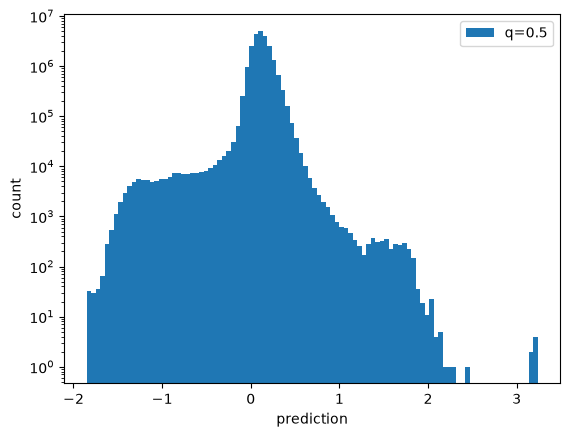

In [38]:
y_pred_q = pnl_threshold_result["y_pred"]
print(np.mean(y_pred_q, axis=0), np.std(y_pred_q, axis=0))
_ = plt.hist(y_pred_q[:, 2], bins=100, log=True, density=False, label=[f"q={q}" for q in QUANTILES[2:3]])
plt.legend()
plt.xlabel("prediction")
plt.ylabel("count")

In [20]:
model = pipeline.model

In [21]:
pipeline.save_pipeline('./dump/')

{'version': 3,
 'created_at': '2026-07-11T23:09:44.557657+00:00',
 'run': {'stamp': '20260711T2309', 'hash': 'c18b058f'},
 'target': 'forward_mid_return_bps',
 'features': ['imb_d1',
  'imb_d3',
  'imb_d5',
  'weighted_price_sz2',
  'weighted_price_sz5',
  'weighted_price_sz10',
  'trade_momentum_hl1s',
  'push_momentum_hl1s',
  'pull_momentum_hl1s',
  'trade_corr_side_hl1s',
  'trade_corr_volume_hl1s',
  'log_return_hl1s',
  'ewma_spread_hl1s',
  'trade_momentum_hl10s',
  'push_momentum_hl10s',
  'pull_momentum_hl10s',
  'trade_corr_side_hl10s',
  'trade_corr_volume_hl10s',
  'log_return_hl10s',
  'ewma_spread_hl10s',
  'trade_momentum_hl30s',
  'push_momentum_hl30s',
  'pull_momentum_hl30s',
  'trade_corr_side_hl30s',
  'trade_corr_volume_hl30s',
  'log_return_hl30s',
  'ewma_spread_hl30s',
  'trade_momentum_hl120s',
  'push_momentum_hl120s',
  'pull_momentum_hl120s',
  'trade_corr_side_hl120s',
  'trade_corr_volume_hl120s',
  'log_return_hl120s',
  'ewma_spread_hl120s',
  'ewma_var_